<center><h1> The Annotated Vision Transformer</h1> </center>

<center>
<p><a href="https://arxiv.org/pdf/2010.11929">AN IMAGE IS WORTH 16X16 WORDS:
TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE
</a></p>
</center>

The Vision Transformer (ViT) is a landmark model that redefined how deep learning can be applied to images.
Building on the success of Transformers in natural language processing, Dosovitskiy et al. (2020) asked a
simple but revolutionary question: *Can we treat an image as a sequence of patches in the same way we treat
a sentence as a sequence of words?*

This notebook follows the same pedagogical style of **The Annotated Transformer**, and we aim to explain the ViT
architecture part-by-part using annotated code, along with diagrams/visualisations, and a minimal working CPU-ready
implementation. We aim to maximize our understanding of how Transformers can operate directly on images and why this approach scales so effectively.

In the following sections, we explore the motivation behind ViT, analyze its architecture, walk through its
training pipeline, and implement a miniature Vision Transformer trained on the MNIST dataset.


# Prelims

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
import math
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Background

## Problem Statement

For nearly a decade, convolutional neural networks (CNNs) dominated computer vision. Their success came from
strong inductive biases local receptive fields, translation equivariance, and hierarchical feature extraction.
However, these same inductive biases can also restrict flexibility and limit scalability. As datasets and compute grew, researchers began to question whether CNN-specific structures were still necessary, or whether a more general architecture could learn visual representations directly from data.

At the same time, Transformers achieved unprecedented success in natural language processing by relying solely on
attention mechanisms and minimal architectural assumptions. This raised a fundamental question:

> **Can we apply Transformers directly to image patches and eliminate convolution entirely?**

The challenge, however, was non-trivial: images are high-dimensional, and Transformers typically require extremely
large datasets to train effectively.

---

## Key Breakthroughs

The Vision Transformer (ViT) introduces several innovations that enable a Transformer to process images:

### **• Patch Tokenization**

Instead of processing raw pixels, ViT divides an image into fixed-size patches (e.g., 16×16). Each patch is flattened
and projected into a vector, allowing the model to reinterpret the 2D image as a simple 1D sequence, analogous to words in a sentence.

### **• Learnable Positional Embeddings**

Unlike CNNs, Transformers have no inherent notion of spatial structure. ViT introduces **learnable positional embeddings**
that encode the location of each patch, which then enables the model to understand spatial relationships.

### **• Pure Transformer Encoder**

ViT removes convolution entirely. The model relies only on the standard Transformer encoder:  
multi-head self-attention layers, feedforward blocks, layer normalization, and residual connections.  

### **• Scaling with Data**

A key finding from the paper is that **Transformers outperform CNNs only when trained on very large datasets**
(such as ImageNet-21k or JFT-300M). ViT demonstrated that increased model capacity improves performance with data size just as attention-based models in NLP.

---

## Summary of Contributions

The ViT paper establishes the following:

- A **pure attention-based model** can match or outperform CNNs on large-scale image classification.
- Treating images as **sequences of patches** is indeed an effective strategy.
- Transformer models in vision demonstrate **predictable scaling behavior** when data is abundant.
- A simple, modular architecture can serve as a **general-purpose backbone** for a wide range of vision tasks.

By revealing that convolution is not strictly necessary for high-performance vision models, ViT fundamentally
reshaped the landscape of modern computer vision research.


# Model Architecture

The Vision Transformer reinterprets an image as a sequence of patches, processes the sequence using a Transformer
encoder, and produces an image-level representation via a special learnable *classification token* (CLS). In this section, we break down each component of the ViT architecture.


## Architecture Overview

The Vision Transformer (ViT) replaces convolutional feature extraction with a sequence-processing architecture.
An image is divided into fixed-size patches, each patch is flattened and linearly projected into an embedding,
and the resulting sequence of embeddings is fed through a standard Transformer Encoder.

To enable global classification, ViT prepends a learnable **[CLS] token** to the patch sequence. After passing
through all Transformer layers, the output embedding corresponding to the [CLS] token is fed into a classifier head.

The core idea: **Images → Patches → Tokens → Transformer → Classification**.


> **Figure:** Vision Transformer Architecture

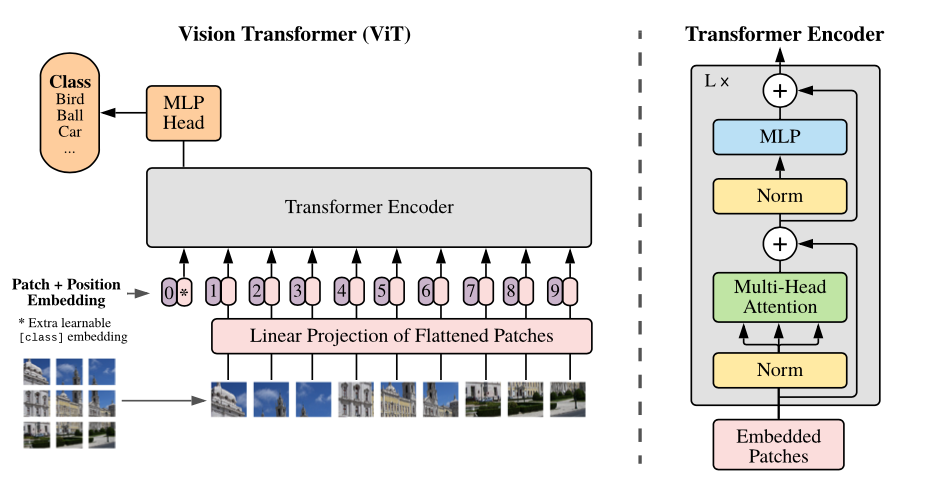
<br>
[Source: Dosovitskiy et al., 2020, Figure 1](https://arxiv.org/abs/2010.11929)


### Visual Intuition

Think of an image as a grid of small tiles. Each tile becomes a “word” in a sentence, and the Transformer
reads the sentence of tiles. Because self-attention considers all tokens simultaneously, ViT can easily model
long-range spatial relationships early in the network which is something CNNs only achieve in deeper layers.


## Patch Embeddings

The first step of ViT is to convert an image into a sequence of patches. For an image of size
$H \times W \times 3$ and a patch size of $P \times P$, we obtain:

$
N = \frac{H \times W}{P^2}
$

patches.

Each patch is flattened into a vector of size $P^2 \cdot 3$, then projected through a trainable linear
layer into the model dimension $D$. The result is a sequence of $N$ embeddings of dimension $D$.

This operation replaces the convolutional stem of CNNs, which then allows the Transformer to treat an image as a
sequence of tokens.

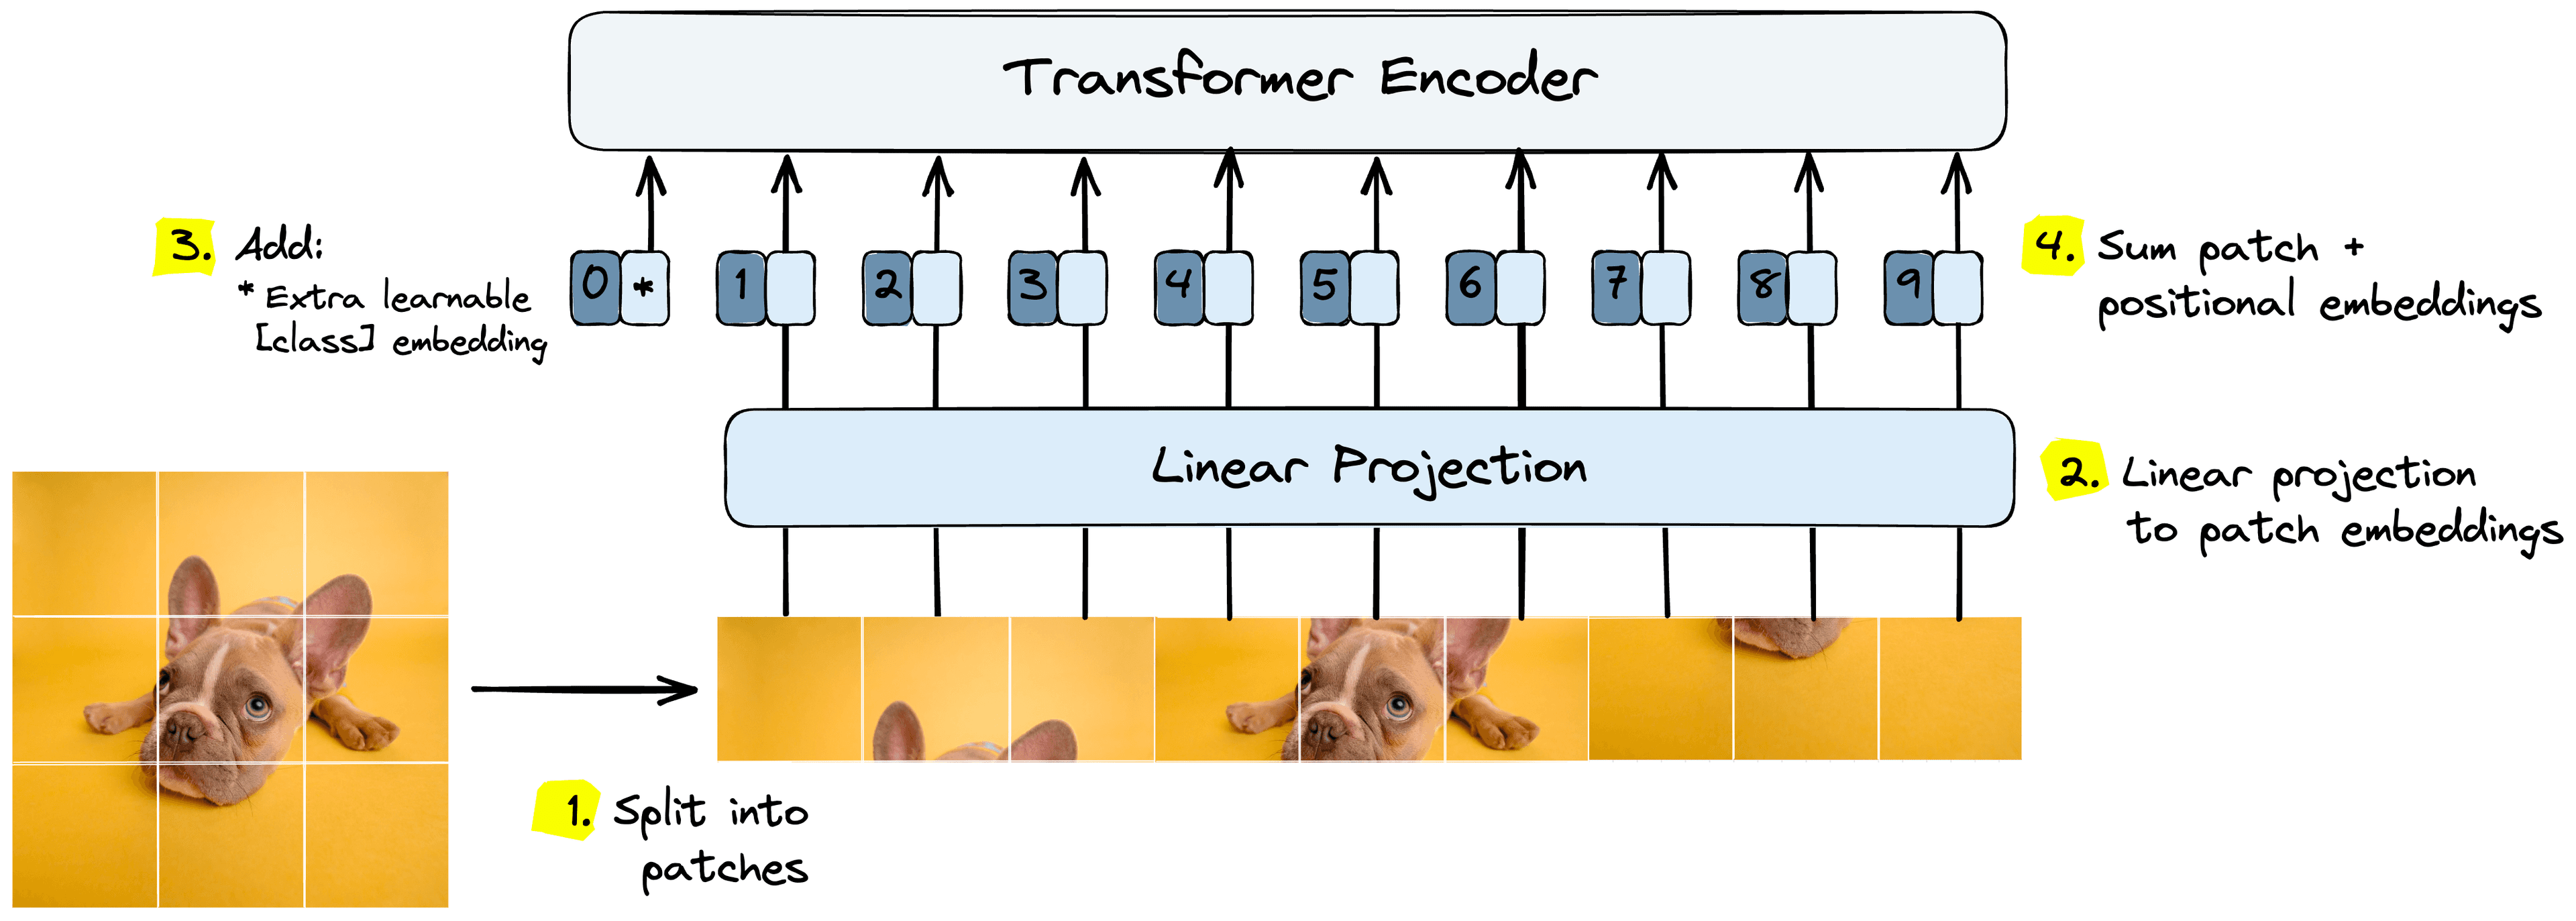
<br>  
[Source](https://www.pinecone.io/_next/image/?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2Fvr8gru94%2Fproduction%2F7a096efc8f3cc40849ee17a546dc0e685da2dc73-4237x1515.png&w=3840&q=75) 

In [2]:
class PatchEmbedding(nn.Module):
    """
    Splits the image into patches, flattens them, and applies a linear projection.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Each patch is treated like a convolutional kernel with stride=patch_size
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.proj(x)         #  (B, embed_dim, H/P, W/P)
        x = x.flatten(2)         #  (B, embed_dim, N)
        x = x.transpose(1, 2)    #  (B, N, embed_dim)
        return x


### Visual Intuition

You can think of a patch embedding layer as essentially a convolutional layer with:

- kernel size = patch size  
- stride = patch size  
- number of output channels = embedding dimension  

This means each kernel kind of “reads” a patch and outputs one token embedding which somehow gives us a compact way to slice an image into patches without any manual reshaping operations.


Below we visualize how a 28×28 MNIST digit is split into 7×7 patches.  
Since our mini-ViT uses a patch size of 7, the image decomposes into a 4×4 grid of patches, resulting in **16 patch tokens**, each processed independently by the Transformer.


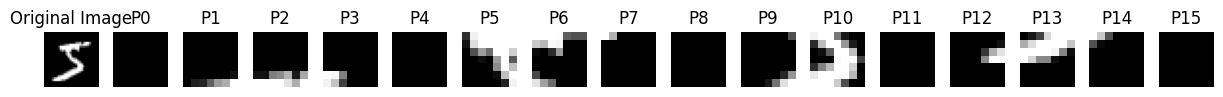

In [3]:
# Load MNIST sample
x_train = datasets.MNIST(root="./data", train=True, download=True).data.numpy()
img = x_train[0]  # first image, shape 28x28
img = img.astype(np.float32) / 255.0

# Patch extraction parameters
patch_size = 7
patches = []

# Extract 7x7 patches
for i in range(0, 28, patch_size):
    for j in range(0, 28, patch_size):
        patch = img[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

# Plot original + patches
fig = plt.figure(figsize=(12, 2))
grid_cols = len(patches) + 1

# Plot original image
plt.subplot(1, grid_cols, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot each patch
for idx, p in enumerate(patches):
    plt.subplot(1, grid_cols, idx + 2)
    plt.imshow(p, cmap="gray")
    plt.title(f"P{idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Positional Embeddings

Transformers have no inherent sense of spatial order. While CNNs encode locality and translation information
using convolution, attention layers treat tokens as unordered sets.

To encode spatial structure, ViT adds **learnable positional embeddings** to each patch embedding:

$
\text{Token}_i = \text{PatchEmbed}_i + \text{PosEmbed}_i
$

These embeddings allow the model to learn the geometry of the image during training.


In [4]:
class AddPositionEmbedding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))  # +1 for CLS token

    def forward(self, x):
        return x + self.pos_embed


### Visual Intuition

Imagine you cut an image into patches and just shuffled them, then the model would have no idea which patch belongs
where. Positional embeddings act like some coordinates that tell the Transformer the “address” of each patch.

These embeddings are *learned*, not fixed which allows ViT to adaptively discover spatial relationships.


## CLS Token

Inspired by BERT, ViT introduces a special **classification token**, prepended to the input sequence:

- It is indeed a learned vector just as the positional embeddings
- It attends to all patch tokens
- After all Transformer layers, its final embedding becomes the image-level representation

This mechanism replaces the global pooling used in CNNs.


In [5]:
class AddCLSToken(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # replicate for batch
        return torch.cat((cls_tokens, x), dim=1)       # prepend CLS token

### Visual Intuition

The CLS token acts just like the “summary” token. All transformer layers allow it to gather information from patch
tokens globally. Think of it as asking every patch:

> “Tell me what you saw so I can summarize the entire image.”

At the end, only the CLS embedding is fed into the classifier.


## Transformer Encoder Block

Each ViT layer is a standard Transformer encoder block consisting of:

1. **LayerNorm**
2. **Multi-Head Self-Attention (MSA)**
3. **Residual connection**
4. **Feedforward MLP block**
5. **Residual connection**

This architecture allows every patch token (including the CLS token) to attend to every other token, which allows capturing of long-range spatial dependencies.


> **Figure:** Transformer Encoder Block

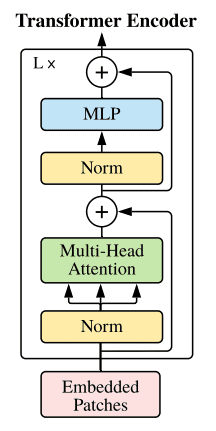
<br>
[Source: Dosovitskiy et al., 2020, Figure 1](https://arxiv.org/abs/2010.11929)



In [6]:
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(self.act(self.fc1(x))))


In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        # Multi-head attention with residual
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]

        # Feedforward network with residual
        x = x + self.mlp(self.norm2(x))
        return x


### Visual Intuition

Self-attention kind of lets every patch compare itself to every other patch:

- A corner patch can attend to the opposite corner  
- Global shape can be recognized early  
- Local texture is not forced, so the model learns what matters the most  

Residual connections serve the role of stabilizing training and allow each block to adjust features incrementally, rather than rebuilding them every time.

## Stacking Transformer Layers

In ViT-Base, the encoder consists of 12 identical layers; ViT-Large uses 24 layers.
The simplicity of the block allows ViT to be scaled easily by increasing depth, width, or attention heads.

A stack of Transformer blocks processes the patch sequence repeatedly, which refines both patch-level and global
representations.


In [8]:
class TransformerEncoder(nn.Module):
    def __init__(self, depth, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


## Classification Head

After all Transformer layers process the sequence, we extract only the final representation of the CLS token.
This vector is fed through a simple MLP head that outputs class probabilities.

This design mirrors BERT-style classification.


In [ ]:
class ClassificationHead(nn.Module):
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        cls_token = x[:, 0]      # extract CLS token
        return self.fc(self.norm(cls_token))


## Synthesis: Full Forward Pass

We now assemble all components : patch embedding, positional embedding, CLS token, transformer encoder, and
classification head into a single Vision Transformer model.


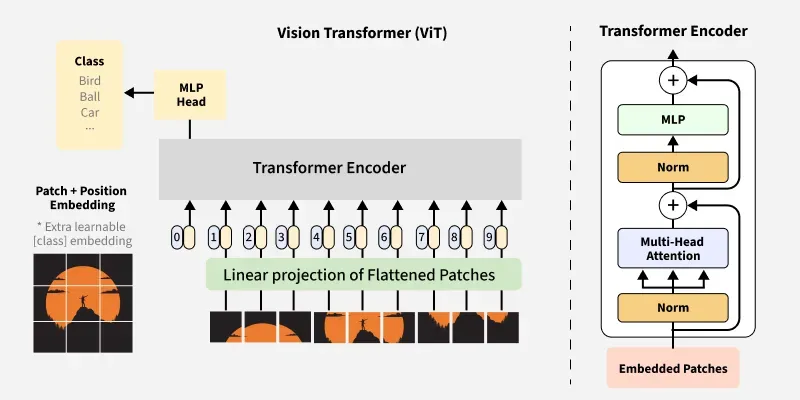
 
[Source](https://media.geeksforgeeks.org/wp-content/uploads/20250108160202257232/Vision-Transformer-Architecture_.webp)


In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=1000, embed_dim=768, depth=12, num_heads=12):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.encoder = TransformerEncoder(depth, embed_dim, num_heads)
        self.head = ClassificationHead(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)                                   # (B, N, D)
        cls_token = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        x = torch.cat((cls_token, x), dim=1)                       # prepend CLS

        x = x + self.pos_embed                                     # positional info
        x = self.encoder(x)                                        # transformer layers
        x = self.head(x)                                           # classification head
        return x


# Model Training

Training the Vision Transformer (ViT) requires careful design of the optimization setup, learning rate schedule, and
regularization strategy. Unlike CNNs, which benefit from strong inductive biases, Transformers demand large
datasets and stabilization techniques to converge. In this section, we break down the sub-parts of the
training pipeline, w.r.t to the details used in the ViT paper.


## Optimization (AdamW)

The original ViT paper trains all models, including ResNets for comparison using **Adam** with:

- β₁ = 0.9  
- β₂ = 0.999  
- batch size = 4096  
- **high weight decay of 0.1**

This choice differs from common practice in CNNs, where stochastic gradient descent (SGD) with momentum is
preferred. Surprisingly, the authors show that **Adam works slightly better than SGD** in their large dataset setting; which makes us question why exactly **Adam**.

### Why Adam/AdamW?

Transformers contain:

- LayerNorm layers  
- Attention projections  
- Deep stacked MLPs  

Adam does stabilize optimization in such architectures by adapting the learning rate per parameter.  
In modern implementations, the optimized version **AdamW** (decoupled weight decay) is preferred because
it separates L2 regularization from gradient updates which improves convergence in high-capacity models.


In [11]:
model = nn.Linear(10, 10)  # placeholder for demonstration
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,           # ViT paper used many base LR (Table 3)
    betas=(0.9, 0.999),
    weight_decay=0.1   # this is per the ViT paper recommendation
)


### Visual Intuition

AdamW gives each parameter its own "step size" and reduces unnecessary weight growth using **weight decay**.

This is essential because attention layers and large MLPs can easily overfit or diverge without strong control.


## Learning Rate Warmup + Decay

Transformers are sensitive to large initial learning rates. To stabilize early training, ViT uses:

1. **Linear Warmup**  
   which gradually increases the learning rate from 0 → base LR over 10,000 steps.

2. **Learning Rate Decay**  
   After warmup, ViT uses either:  
   - **Linear decay** (default), or  
   - **Cosine decay**

Warmup prevents the optimizer from making aggressive updates at the start when weights are poorly initialized.  
Decay ensures the model converges smoothly as training progresses.


In [12]:
def lr_schedule(step, warmup_steps=10000, total_steps=200000):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay

scheduler = LambdaLR(optimizer, lr_lambda=lr_schedule)


## Regularization

Because ViT contains **no convolutional inductive biases**, it is more prone to overfitting and generally harder to optimize

The paper shows that **strong regularization is crucial**. Techniques include:

### 1. Weight Decay  
A very high value (0.1) is used across the majority of experiments.

### 2. Dropout  
Applied after:
- Dense layers in MLP blocks  
- Addition of positional embeddings  
Not applied inside qkv projections.

### 3. Gradient Clipping  
On ImageNet, clipping at global norm 1 stabilizes training.

In our minimal CPU example, we will use a simpler setup (small dropout + weight decay), similar to those used in the ViT paper.


In [13]:
# Example of dropout inside the MLP block
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout1(self.act(self.fc1(x)))
        x = self.dropout2(self.fc2(x))
        return x


### Visual Intuition

Transformers are very expressive: without constraints, they tend to just memorize.  
Dropout and weight decay act like “noise injections” that force the model to generalize, while gradient clipping
keeps the training dynamics under control.


## Loss Function (Cross-Entropy)

ViT is primarily evaluated on classification tasks, so the objective is the standard cross-entropy loss:

$$
\mathcal{L} = -\sum_{c} y_c \log(p_c)
$$

Where:
- $y_c$ is the one-hot target label  
- $p_c$ is the predicted class probability  

For MNIST (our MWE), we will use the same loss.


In [14]:
criterion = nn.CrossEntropyLoss()

## Training Loop

The training loop performs the following key operations:

1. **Forward Pass**  
   Compute patch embeddings → positional embeddings → Transformer encoder → classifier head.

2. **Loss Computation**  
   Cross-entropy between predictions and ground truth.

3. **Backward Pass**  
   Compute gradients via autograd.

4. **Optimizer Step**  
   Update parameters using AdamW.

5. **Learning Rate Update**  
   Scheduler adjusts the learning rate (warmup + decay).

6. **Regularization**  
   Dropout and weight decay applied automatically.

7. **Evaluation**  
   Validation accuracy/loss computed every epoch or few steps.

This process is repeated across all epochs until convergence.


In [15]:
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for step, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # optional for stability

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # compute training accuracy
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc


# Minimal Working Example (MWE-CPU)

To maximize our understanding of the Vision Transformer architecture, we now implement a **miniaturized ViT** and
train it on the MNIST dataset. MNIST is small, grayscale, and easy to visualize which makes it a perfect candidate
for CPU experiments. The goal here is not to achieve state-of-the-art performance, but rather to gain
insight into how the model behaves when trained end-to-end.

We follow three main steps:

1. **Prepare the dataset** (MNIST, converted to patch sequences).  
2. **Define a compact ViT model** that runs on CPU.  
3. **Train and analyze** the model’s output and training dynamics.

This MWE mirrors the core ideas of ViT while remaining efficient and easy to inspect.


## MNIST Data Preparation

MNIST consists of 60,000 training and 10,000 test images of handwritten digits. Each image is:

- 28 × 28 pixels  
- Grayscale  
- Single-channel (1 input channel instead of 3)

To fit our patching strategy, we use a patch size of 7 × 7, producing:

$$
N = (28 / 7)^2 = 16 \text{ patches}
$$

Each patch becomes a token fed to the mini-ViT.


In [16]:
# MNIST transformation: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]


### Visual Intuition

Think of each 28×28 MNIST digit as a 4×4 grid of patches.  
Each 7×7 patch becomes a small "word" in a 16-token "sentence,"  
which we then need to feed into the Transformer.


## Mini-ViT Architecture

To ensure the model trains quickly on CPU, we reduce the scale of the original ViT:

| Component              | ViT-Base | Mini-ViT (CPU) |
|------------------------|----------|-----------------|
| Embedding dimension    | 768      | 64              |
| Patch size             | 16×16    | 7×7             |
| Number of patches      | 196      | 16              |
| Transformer layers     | 12       | 3               |
| Attention heads        | 12       | 4               |
| MLP hidden dimension   | 3072     | 128             |
| Parameters             | 86M      | ~0.5M           |

This model variant retains the full ViT structure but remains somewhat lightweight and interpretable.


In [17]:
class MiniVisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=28,
        patch_size=7,
        in_channels=1,
        num_classes=10,
        embed_dim=64,
        depth=3,
        num_heads=4,
        mlp_ratio=2.0
    ):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # CLS token + positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Transformer encoder
        self.encoder = TransformerEncoder(depth, embed_dim, num_heads, mlp_ratio, dropout=0.1)

        # Classification head
        self.head = ClassificationHead(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        # Add CLS token
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        # Add positional embeddings
        x = x + self.pos_embed

        # Transformer encoder
        x = self.encoder(x)

        # Classification
        return self.head(x)


### Visual Intuition

Compared to the full ViT, this mini-version is like a compact Transformer encoder:

- Fewer layers → shallower reasoning  
- Fewer heads → simpler attention patterns  
- Smaller embeddings → faster CPU training  

Yet, it still captures the essential design of ViT.


## Training Loop (CPU)

We now train the mini-ViT for a few epochs. Even on CPU, this takes only a few minutes. We use:

- AdamW optimizer  
- Cosine decay learning rate schedule  
- Cross-entropy loss  

Our objective is to observe training behavior and verify the architecture functions correctly.


In [18]:
device = torch.device("cpu")

model = MiniVisionTransformer().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    weight_decay=0.05
)

# simple cosine scheduler (no warmup for MNIST)
scheduler = LambdaLR(optimizer, lr_lambda=lambda step: 0.5 * (1 + math.cos(step / 2000)))


In [19]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc


In [20]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )


Epoch 1/5 | Train Loss: 0.8382, Train Acc: 73.26% | Val Loss: 0.3052, Val Acc: 90.93%
Epoch 2/5 | Train Loss: 0.2897, Train Acc: 91.22% | Val Loss: 0.1700, Val Acc: 94.59%
Epoch 3/5 | Train Loss: 0.1980, Train Acc: 94.05% | Val Loss: 0.1368, Val Acc: 95.74%
Epoch 4/5 | Train Loss: 0.1519, Train Acc: 95.45% | Val Loss: 0.1217, Val Acc: 96.18%
Epoch 5/5 | Train Loss: 0.1268, Train Acc: 96.16% | Val Loss: 0.1056, Val Acc: 96.74%


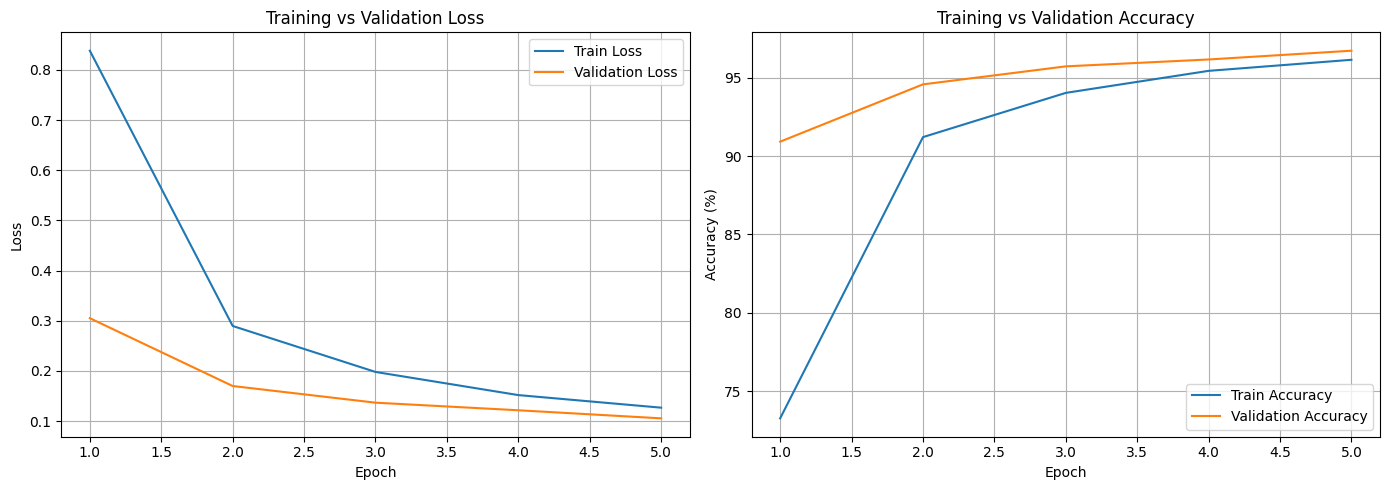

In [21]:
epochs = range(1, num_epochs + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
axs[0].plot(epochs, train_losses, label="Train Loss")
axs[0].plot(epochs, val_losses, label="Validation Loss")
axs[0].set_title("Training vs Validation Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)
axs[0].legend()

# Accuracy subplot
axs[1].plot(epochs, [acc * 100 for acc in train_accuracies], label="Train Accuracy")
axs[1].plot(epochs, [acc * 100 for acc in val_accuracies], label="Validation Accuracy")
axs[1].set_title("Training vs Validation Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()



## Evaluation

To measure how well the mini-ViT learned to classify MNIST digits, we compute accuracy on the test set.


In [22]:
accuracy = evaluate(model, test_loader, criterion, device)[1]
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 96.74%


## Discussion of Training Outcome

Our mini-ViT achieved a training loss that steadily decreased across epochs (from **0.83 → 0.12**) and reached a
final **test accuracy of 96.74%** on MNIST. This is a strong result for such a compact Transformer that operates
without convolutional inductive biases. Although MNIST is a simple dataset, surpassing 96% accuracy
demonstrates that even a shallow ViT can effectively learn spatial patterns from patch-based representations.

### What We Learn from the MWE

- **Patch embeddings work well even on small 28×28 grayscale images.**  
- **Self-attention successfully models digit structure without convolutions.**  
- **The CLS token learns to summarize global image information.**  
- **Even a 3-layer Transformer with small embedding size learns meaningful spatial features.**  
- **Training dynamics are stable with AdamW and cosine decay, even on CPU.**

### Interpreting the Results

ViT was originally designed for large-scale datasets such as ImageNet-21k and JFT-300M. MNIST is far smaller and
less complex, so high accuracy here reflects dataset simplicity more than model capacity. The purpose of this MWE
is conceptual clarity: understanding how images are transformed into token sequences, how attention processes them,
and how the architecture behaves during training.

This experiment highlights that ViT’s core ideas remain functional even at very small scales.


## Fine-tuning
The pre-trained model is then fine-tuned on smaller, more specific downstream tasks.

During pre-training, the classification head is a slightly larger MLP with one hidden layer. This larger MLP is then replaced during fine-tuning step by a single feed-forward $ D \times K $ layer, where K is the number of classes. As per the paper, the fine-tuning should be done on higher resolution images, keeping the patch size same. This will lead in a larger number of patches per image, however, the model can handle arbitrary number of patches, as long as they can fit in the memory and the patch size is the same. However, in this case, the pre-trained positional embeddings might not be very meaningful. To solve this, 2D interpolation of the pre-trained embeddings is done based on their locations in the image.

For our application, we will be using the FashionMNIST [(Xiao et. al., 2017)](https://arxiv.org/abs/1708.07747) dataset. The reason for using this dataset is that it is a common replacement/alternative for the MNIST dataset, it also has the same image size, number of samples and number of classes. Since the images are of the same resolution, there is no need to do a 2D interpolation of position embeddings.<br><br>
NOTE: Ideally, fine-tuning should be done on a dataset similar to what the model is already trained on, while, mnist and fashion mnist are fairly different datasets (one classifies numbers, other classifies clothing items). Therefore, there might be a high chance that the performance of the pre-trained model fine-tuned on this dataset might be bad. But it demonstrates the concept/technique just as well.


In [23]:
# MNIST transformation: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset_fashion = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset_fashion  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Dataloaders
train_loader_fashion = DataLoader(train_dataset_fashion, batch_size=64, shuffle=True)
test_loader_fashion  = DataLoader(test_dataset_fashion, batch_size=256, shuffle=False)


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.09MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 143kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.67MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


#### Defining the fine-tuning model architecture

In [24]:
class MiniVisionTransformerFineTuning(nn.Module):
    def __init__(
        self,
        img_size=28,
        patch_size=7,
        in_channels=1,
        num_classes=10,
        embed_dim=64,
        depth=3,
        num_heads=4,
        mlp_ratio=2.0
    ):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # CLS token + positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Transformer encoder
        self.encoder = TransformerEncoder(depth, embed_dim, num_heads, mlp_ratio, dropout=0.1)

        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)
        # initializing the weights to 0
        torch.nn.init.zeros_(self.head.bias)
        torch.nn.init.zeros_(self.head.weight)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        # Add CLS token
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        # Add positional embeddings
        x = x + self.pos_embed

        # Transformer encoder
        x = self.encoder(x)

        # get the class token's embeddings only
        cls_token_embedding = x[:, 0]

        # Classification
        return self.head(cls_token_embedding)


#### Performing the fine-tuning
A few details about the fine-tuning:
1. For the optimizer, _ADAM_ [(Kingma & Ba, 2015)](https://arxiv.org/abs/1412.6980) will be used. The parameters will be the same as that in the paper, $ \beta_1 = 0.99 $, $ \beta_2 = 0.999 $ and weight decay of 0.00. Learning rate will be 0.0003 (the default value). These values work well for the dataset, and are not fine-tuned for this exercise.
2. The batch size will be 64.
3. The model will be trained for 5 epochs.
4. Since this is a classification problem, cross entropy loss will be used as the loss function.

Since this is fine-tuning, we have the option of freezing (basically they will not be updated during the training) the pre-trained weights. However, we need to think about how many and what layers should we be freezing:
- We can freeze all the layers except the final classification head. However, the shift from mnist to fashion mnist is relatively big, so this might not be a good idea.
- We can train all the layers.
- We can freeze the initial layers, and train only the later ones. This is the best 'middle ground'. Therefore, we will be doing this. We will be freezing the embedding layers.

In [25]:
# declaring the fine tuning model
ft_model = MiniVisionTransformerFineTuning().to(device)

# loading the state dict from the pre-trained model on the MNIST dataset
filtered_dict = {k:v for k,v in model.state_dict().items() if 'head.' not in k}

# loading these weights
ft_model.load_state_dict(filtered_dict, strict=False)

_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=[])

The warning above is complaining about the state dict not having the classification_head's weights and biases. But that is by design. We are good.

In [26]:
# freezing the embedding layer
for name, p in ft_model.named_parameters():
    if name in ['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias']:
        p.requires_grad = False

In [27]:
# loading the optimizer
optimizer = optim.AdamW(
    ft_model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    weight_decay=0.00
)

# simple cosine scheduler (no warmup for MNIST)
scheduler = LambdaLR(optimizer, lr_lambda=lambda step: 0.5 * (1 + math.cos(step / 2000)))

In [28]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(ft_model, train_loader_fashion, optimizer, scheduler, criterion, device)
    val_loss, val_acc = evaluate(ft_model, test_loader_fashion, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )


Epoch 1/5 | Train Loss: 0.7782, Train Acc: 71.44% | Val Loss: 0.5952, Val Acc: 78.37%
Epoch 2/5 | Train Loss: 0.5176, Train Acc: 81.40% | Val Loss: 0.4891, Val Acc: 82.65%
Epoch 3/5 | Train Loss: 0.4543, Train Acc: 83.52% | Val Loss: 0.4566, Val Acc: 83.71%
Epoch 4/5 | Train Loss: 0.4190, Train Acc: 84.77% | Val Loss: 0.4360, Val Acc: 84.45%
Epoch 5/5 | Train Loss: 0.3960, Train Acc: 85.57% | Val Loss: 0.4249, Val Acc: 85.05%


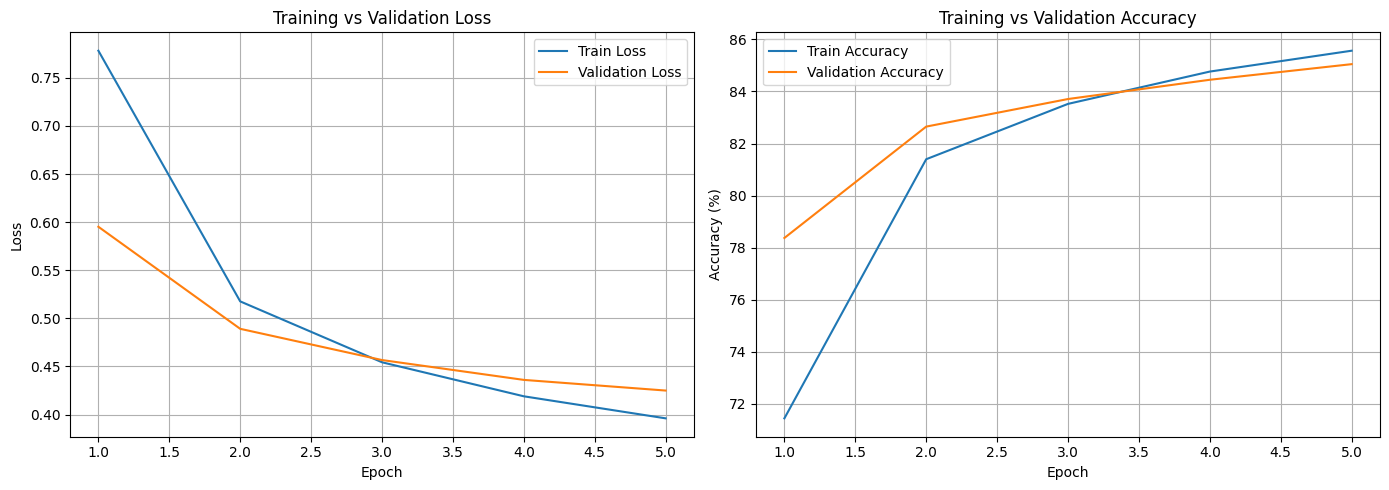

In [29]:
epochs = range(1, num_epochs + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
axs[0].plot(epochs, train_losses, label="Train Loss")
axs[0].plot(epochs, val_losses, label="Validation Loss")
axs[0].set_title("Training vs Validation Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)
axs[0].legend()

# Accuracy subplot
axs[1].plot(epochs, [acc * 100 for acc in train_accuracies], label="Train Accuracy")
axs[1].plot(epochs, [acc * 100 for acc in val_accuracies], label="Validation Accuracy")
axs[1].set_title("Training vs Validation Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()



Evaluating the fine-tuned model on test data.

In [30]:
accuracy = evaluate(ft_model, test_loader_fashion, criterion, device)[1]
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 85.05%


## Inspecting the Visual Transformer
To understand how the vision transformer learns and processes image data, we are going to analyze it's internal representations:
<br> NOTE: This will be done on the trained model and not the fine-tuned model.

### Embedding filters
The first layer of the model creates patch embeddings of the image using a linear transformation of the image patches. We do this using the conv2D layer. We plot the weights of this conv2D layer, $ 7 \times 7 $ in shape to understand if these filters look like any plausible detectors or have plausible shapes (such as lines etc) or not.

In [31]:
patch_weights = model.patch_embed.proj.weight.data  # state_dict()['weight']
patch_weights.shape

torch.Size([64, 1, 7, 7])

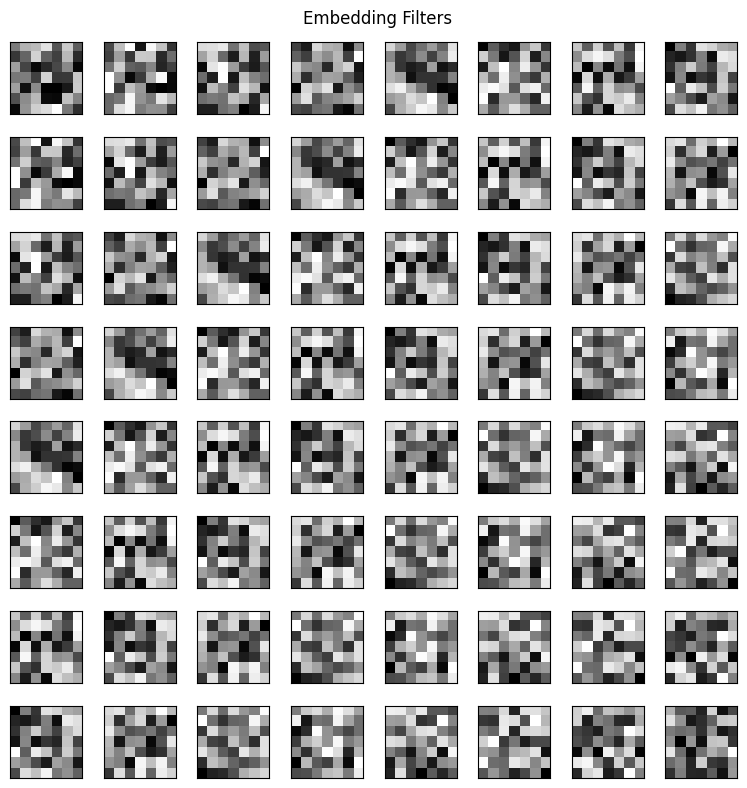

In [32]:
fig = plt.figure(figsize=(15, 8))

outer = gridspec.GridSpec(1, 2, width_ratios=[2, 2])

inner = gridspec.GridSpecFromSubplotSpec(
    8, 8, subplot_spec=outer[1], wspace=0.3, hspace=0.3
)

for i in range(8):
    for j in range(8):
        axi = fig.add_subplot(inner[i,j])
        axi.imshow(patch_weights[i+j, 0], cmap='binary')
        axi.set_xticks([])
        axi.set_yticks([])

fig.suptitle("Embedding Filters", x=0.75)

plt.tight_layout()
plt.show()


In theory, the patches should look like fundamental basis functions (such as line detectors etc.). However, majority of them do not really look plausible and look like random noise. This could be because of the dataset itself because of the images being relativly simpler compared to datasests such as Imagenet.

### Position embeddings
Once the linear embeddings are created for patches, positional embeddings are created for each patch, describing and/or containing information about the patch's position in the image. Let's plot the similarities of the position embeddings. For this, we are removing the position embeddings for the class token as this token is not part of the image. We will be using cosine similarity. We are going to plot the cosine similarity between an embedding and all the other position embeddings, and plot the similarities as a heatmap. The heatmap will have $ 4 \times 4 $ heatmaps, showing similarity between the patch's position embedding with others.

In [33]:
# getting the position embeddings
pos_weights = model.pos_embed[0, 1:]
pos_weights.shape

torch.Size([16, 64])

In [34]:
# calculating cosine similarity
dots = pos_weights @ pos_weights.T
norm = np.linalg.norm(pos_weights.detach().numpy(), axis=1)

cos_sim_mat = dots.detach().numpy()/np.outer(norm, norm)
cos_sim_mat.shape

(16, 16)

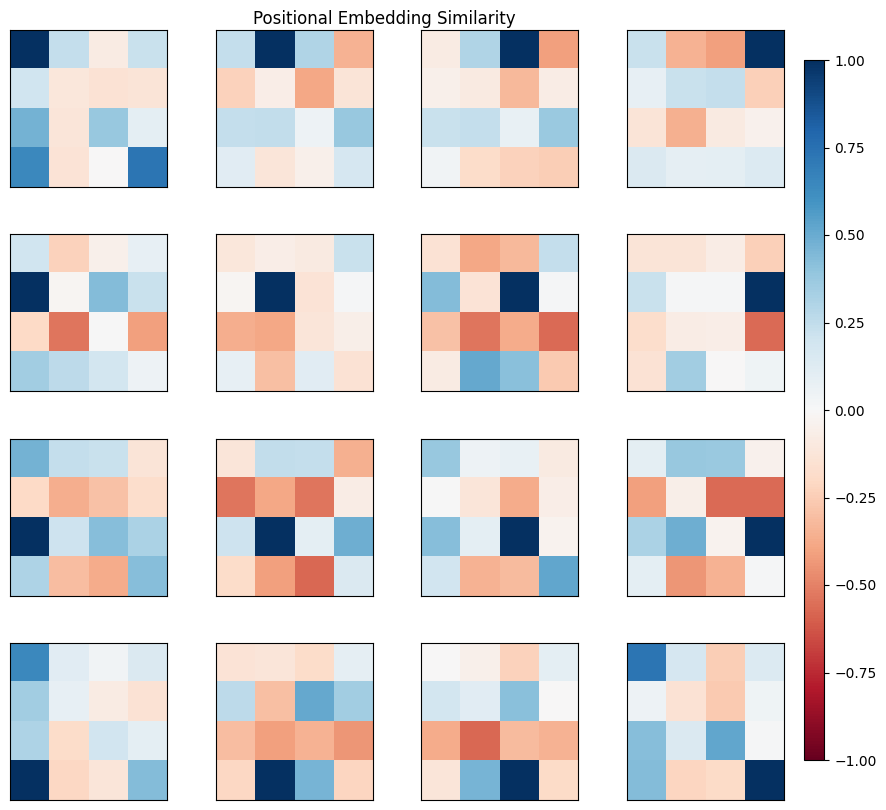

In [35]:
# Create figure
fig = plt.figure(figsize=(10, 10))
outer = gridspec.GridSpec(4, 4, wspace=0.3, hspace=0.3)  # 4x4 grid for 16 images

# Compute min and max for shared color scale
vmin, vmax = -1, 1

for i in range(16):
    row = i // 4
    col = i % 4
    ax = fig.add_subplot(outer[row, col])
    im = ax.imshow(cos_sim_mat[i].reshape(4,4), cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])

# Add single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)

fig.suptitle("Positional Embedding Similarity", y=0.9)
plt.show()

A behaviour (with exceptions) can be seen in some places is that for a given patch, there is higher similarity with patches close to it, as seen by the bright blue spots in many heatmaps. Also, a slight row-column structure can also be seen, showing that, in some places, the row and/or column a patch belongs to has slightly higher cosine similarity relative to other patches.

# Discussion: Weaknesses, Limitations, and Future Directions

The Vision Transformer (ViT) represents indeed a major shift in computer vision, and shows that attention-only
architectures can match or exceed convolutional networks at scale. However, the model also comes with its own
set of challenges and constraints. In this section, we analyze the limitations observed the paper discusses, as well
as promising directions for future research and development.

---

## Weaknesses and Limitations

### **1. Data-Hungry Architecture**
Transformers have fewer inductive biases than CNNs, which means basically that they rely heavily on large-scale datasets to learn spatial features. The original ViT models required:

- ImageNet-21k (14M images), and  
- JFT-300M (300M images)

to somehow reach competitive performance. When trained on small datasets like CIFAR-10 or MNIST, ViT tends to
underperform unless some regularization or augmentation is added.

**Implication:**  
Without massive training data, the model struggles to develop strong low-level visual features.

---

### **2. Lack of Locality Bias**
CNNs naturally capture local patterns (edges, corners, textures) due to their convolutional structure. ViT,
by contrast, must *learn* locality from data. This makes early training less stable and increases complexity.

**Implication:**  
ViT can be inefficient and slower to converge compared to similarly sized CNNs.

---

### **3. Computational Cost at High Resolution**
Self-attention scales quadratically with sequence length:

$$
O(N^2) \quad \text{where } N = \text{number of patches}
$$

High-resolution images produce long patch sequences, which makes attention expensive in:

- memory usage  
- compute time  

**Implication:**  
Scaling ViT to very high resolution (e.g., 1024×1024) can be restraining without further approximation methods.

---

### **4. Sensitivity to Training Hyperparameters**
ViT requires careful tuning of:

- warmup steps  
- learning rate decay  
- weight decay  
- dropout  

So, training can easily diverge or overfit if hyperparameters are not properly set.

**Implication:**  
ViT training is less forgiving than CNN training, especially in the small-data regime.

---

### **5. Limited Interpretability**
Although attention maps offer some insights, they do not always align with human visual reasoning.  
Interpretability remains somewhat an active research area for attention-based vision systems.

---

## Future Directions

Despite its limitations, the Vision Transformer has inspired a large family of new architectures and
continues to evolve. Promising future directions include:

---

### **1. Data-Efficient Training (DeiT and Beyond)**
The DeiT (Data-efficient Image Transformer) work demonstrated that with:

- knowledge distillation  
- strong augmentations  
- optimized training techniques  

ViT models can match CNNs *even without* massive datasets.

**Future direction:**  
Developing techniques that reduce data requirements even further.

---

### **2. Hierarchical Vision Transformers**
Models like Swin Transformer introduce:

- shifting windows  
- hierarchical feature maps  
- linear-time attention  

These inject *useful inductive biases* while keeping the flexibility of Transformers.

**Future direction:**  
Hybrid architectures that combine the strengths of both CNNs and Transformers.

---

### **3. Efficient Attention Mechanisms**
Quadratic attention is the main bottleneck. Research has explored:

- sparse attention  
- linearized attention  
- kernel-based approximations  
- patch merging / pooling strategies

**Future direction:**  
Scaling Transformers to ultra-high-resolution images and video.

---

### **4. Self-Supervised and Multimodal Learning**
ViT excels in settings like:

- masked image modeling (MAE, SimMIM)  
- contrastive learning (DINO)  
- multimodal models (CLIP, ALIGN)  

**Future direction:**  
Using ViT as a backbone for multimodal and self-supervised frameworks.

---

### **5. Vision Transformers for Specialized Domains**
Transformers are now used in:

- medical imaging  
- remote sensing  
- robotics  
- autonomous driving  
- segmentation & detection (SegFormer, DETR architectures)

**Future direction:**  
Domain-specific architectures with tailored positional encodings and patch embeddings.

---

## Summary

While ViT requires considerable data, compute, and tuning, its design and scalability have reshaped
vision research. Many of its limitations are active areas of innovation, and recent work
has improved its efficiency and accessibility.

The minimal MNIST example in this notebook illustrates that even a tiny version of ViT can learn meaningful
visual representations which somehow demonstrates the power and flexibility of the Transformer in computer vision.
